# Alchemy GeomML + TDA — Quickstart (v33+)

Полный пайплайн: загрузка данных → обучение → оценка → AutoML.

**Датасет:** Alchemy v20191129 (202,579 молекул, 12 квантово-механических свойств)

**Модели:** FCNN, SchNet, EGNN, EGNN+TDA, EGNN Vector, EGNN Vector+TDA, **EGNN Tensor** (часть B)

## 1. Установка зависимостей

Если запуск локально (не в Kaggle/Colab):

In [1]:
!pip install torch torch-geometric gudhi rdkit egnn-pytorch pandas matplotlib seaborn pyyaml scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 52.7 MB/s eta 0:00:00


## 2. Клонирование репозитория и загрузка данных

In [2]:
import os
if not os.path.exists('alchemy-geom-tda'):
    !git clone https://github.com/ThomasMoore25/alchemy-geom-tda.git
%cd alchemy-geom-tda
!git log --oneline -1

Cloning into 'alchemy-geom-tda'...
remote: Enumerating objects: 704, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 704 (delta 28), reused 37 (delta 17), pack-reused 644 (from 1)
Receiving objects: 100% (704/704), 3.52 MiB | 16.94 MiB/s, done.
Resolving deltas: 100% (394/394), done.
/kaggle/working/alchemy-geom-tda
c24ee83 (HEAD -> main, origin/main, origin/HEAD) v33.14.1: bump version in src/__init__.py (was stuck at 33.0.0)


In [3]:
# Скачать датасет Alchemy (136 МБ zip, ~600 МБ распакованный)
# Подробный вывод — видно прогресс скачивания и проверки SHA256
!python data/download_alchemy.py

[1/3] Скачиваю Alchemy (v20191129) из https://alchemy.tencent.com/data/alchemy-v20191129.zip (попытка 1/3)
      Размер ~136 МБ, может занять 1-3 минуты ...
[2/3] Проверяю целостность zip ...
      SHA256: 3a3370ec4f8ba4c4a6d15e23824b6c0051d9ce9e8de84e0e0e0548b07d99a653
      zip валиден
[3/3] Распаковываю ...
Готово. Данные в /kaggle/working/alchemy-geom-tda/data/alchemy/Alchemy-v20191129

Структура:
  atom_10/  (119661 SDF файлов)
  atom_11/  (37732 SDF файлов)
  atom_12/  (9331 SDF файлов)
  atom_9/  (35855 SDF файлов)
  final_version.csv  (31.7 МБ)

=== final_version.csv ===
Размер: 202579 молекул × 14 колонок

Колонки:
  0: 'gdb_idx'
  1: 'atom number'
  2: 'zpve\n(Ha, zero point vibrational energy)'
  3: 'Cv\n(cal/molK, heat capacity at 298.15 K)'
  4: 'gap\n(Ha, LUMO-HOMO)'
  5: 'G\n(Ha, Free energy at 298.15 K)'
  6: 'HOMO\n(Ha, energy of HOMO)'
  7: 'U\n(Ha, internal energy at 298.15 K)'
  8: 'alpha\n(a_0^3, Isotropic polarizability)'
  9: 'U0\n(Ha, internal energy at 0 K)'
  

## 3. Проверка окружения

In [4]:
import sys
sys.path.insert(0, 'src')

import torch
import torch_geometric
import egnn_pytorch
import rdkit
import gudhi

print(f'torch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'torch-geometric: {torch_geometric.__version__}')
print(f'rdkit: {rdkit.__version__}')
print(f'gudhi: {gudhi.__version__}')

import src
print(f'\nalchemy-geom-tda version: {src.__version__}')

torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 15.6 GB
torch-geometric: 2.8.0
rdkit: 2026.03.4
gudhi: 3.13.0

alchemy-geom-tda version: 33.14.0


## 4. Smoke-тест (5 минут на CPU, проверка установки)

Обучаем EGNN на 100 молекулах, 2 эпохи. Должен быть виден убывающий loss.

In [5]:
import sys, os
sys.path.insert(0, 'src')
os.makedirs('results/smoke', exist_ok=True)

sys.argv = ['train.py',
    '--model', 'egnn',
    '--target', 'all',
    '--epochs', '2',
    '--max_train', '100',
    '--max_val', '20',
    '--max_test', '20',
    '--batch_size', '32',
    '--device', 'cpu',
    '--output_dir', 'results/smoke',
]

from train import main as train_main
train_main()

Device: cpu
2026-07-19 15:52:45,723 [INFO] Загрузка датасета Alchemy...
[train] Загружаю свойства из data/alchemy/Alchemy-v20191129/final_version.csv ...


Processing...


  Свойств: 202579 молекул
[train] Ищу SDF файлы ...
  Найдено SDF: 202579
  Валидных молекул (SDF + CSV): 202579
[train] Делаю stratified split по gap ...
  Всего: train=162063, val=20257, test=20259
  train: 100 молекул (после max_samples)
  Парсинг SDF: 0/100
[train] Сохраняю 100 молекул в data/alchemy/processed/alchemy_v32_train_max100_83fbc1ddfdb9.pt


Done!
Processing...


[val] Загружаю свойства из data/alchemy/Alchemy-v20191129/final_version.csv ...
  Свойств: 202579 молекул
[val] Ищу SDF файлы ...
  Найдено SDF: 202579
  Валидных молекул (SDF + CSV): 202579
[val] Делаю stratified split по gap ...
  Всего: train=162063, val=20257, test=20259
  val: 20 молекул (после max_samples)
  Парсинг SDF: 0/20
[val] Сохраняю 20 молекул в data/alchemy/processed/alchemy_v32_val_max20_ab1e77a37f33.pt
[test] Загружаю свойства из data/alchemy/Alchemy-v20191129/final_version.csv ...


Done!
Processing...


  Свойств: 202579 молекул
[test] Ищу SDF файлы ...
  Найдено SDF: 202579
  Валидных молекул (SDF + CSV): 202579
[test] Делаю stratified split по gap ...
  Всего: train=162063, val=20257, test=20259
  test: 20 молекул (после max_samples)
  Парсинг SDF: 0/20
[test] Сохраняю 20 молекул в data/alchemy/processed/alchemy_v32_test_max20_954cfd2d281f.pt
2026-07-19 15:52:54,944 [INFO] Train/Val/Test: 100/20/20
2026-07-19 15:52:55,018 [INFO] Target stats (mean, std): {'mu': (2.849484443664551, 1.5876632928848267), 'alpha': (106.13142395019531, 13.389533042907715), 'gap': (0.055006243288517, 0.0059717209078371525)}
2026-07-19 15:52:55,019 [INFO] → args сохранены в results/smoke/args_egnn_all.json
2026-07-19 15:52:55,021 [INFO] → target_stats сохранены в results/smoke/target_stats_egnn_all.json
2026-07-19 15:52:55,021 [INFO] Loader: DataLoader  (multi_gpu=False)
2026-07-19 15:52:55,022 [INFO] Loader kwargs: {'batch_size': 32}
2026-07-19 15:52:55,075 [INFO] Модель: egnn, параметров: 951,759
2026-07

Done!


2026-07-19 15:52:57,344 [INFO] Epoch   1/2 | train_loss=2.5637 | val_loss=3.2812 | mu_mae=1.5752 | alpha_mae=13.5980 | gap_mae=0.0076 | ES=[val_loss: 0/15 | val_mu_mae: 0/15 | val_alpha_mae: 0/15 | val_gap_mae: 0/15] | lr=1.00e-03 | 2.3s | RESET:val_loss,val_mu_mae,val_alpha_mae,val_gap_mae | ★ best
2026-07-19 15:52:59,907 [INFO] Epoch   2/2 | train_loss=2.3907 | val_loss=3.3139 | mu_mae=1.5366 | alpha_mae=13.7747 | gap_mae=0.0079 | ES=[val_loss: 1/15 | val_mu_mae: 0/15 | val_alpha_mae: 1/15 | val_gap_mae: 1/15] | lr=1.00e-03 | 2.6s | RESET:val_mu_mae
2026-07-19 15:52:59,918 [INFO] → Сохранён best checkpoint → egnn_all_best.pt
2026-07-19 15:52:59,919 [INFO] 
=== Финальная оценка на test ===
2026-07-19 15:53:00,010 [INFO]   test_loss: 2.9885
2026-07-19 15:53:00,011 [INFO]   test_mu_mae: 1.3458
2026-07-19 15:53:00,011 [INFO]   test_alpha_mae: 12.3446
2026-07-19 15:53:00,012 [INFO]   test_gap_mae: 0.0073
2026-07-19 15:53:00,014 [INFO] История сохранена в results/smoke/history_egnn_all_202

## 5. Полное обучение одной модели (GPU, ~1-2 часа)

EGNN на полном датасете с быстрым EarlyStopping.

**Параметры для быстрой сходимости:**
- `--epochs 9999` (EarlyStopping остановит раньше)
- `--patience 10` (вместо 15)
- `--es_mode or` (стоп при первой плохой метрике)
- `--batch_size 1024` (если GPU позволяет)

In [6]:
# #Раскомментировать для полного запуска (нужен GPU)

# sys.argv = ['train.py',
#     '--model', 'egnn',
#     '--target', 'all',
#     '--epochs', '9999',
#     '--batch_size', '1024',
#     '--hidden_channels', '128',
#     '--num_layers', '4',
#     '--lr', '1e-3',
#     '--lr_patience', '4',
#     '--device', 'cuda',
#     '--patience', '10',
#     '--es_mode', 'or',
#     '--num_workers', '4',
#     '--output_dir', 'results/experiments/batch_size_1024',
#     '--multi_gpu',
# ]
# from train import main as train_main
# train_main()

## 6. EGNN Tensor — часть B (вектор μ + тензор α)

**EGNN Tensor** (v33.0+, программа максимума) — физически корректная модель:
- Предсказывает **вектор** дипольного момента μ ∈ R³ (а не скаляр |μ|)
- Предсказывает **тензор** поляризуемости α ∈ R^(3×3) (а не скаляр tr(α)/3)
- Через частичные заряды атомов: q_i = MLP(h_atom)
- μ = Σᵢ qᵢ · (rᵢ − COM), α = Σᵢ qᵢ · (rᵢ − COM) ⊗ (rᵢ − COM)

**Чем отличается от обычного EGNN:**
- Обычный EGNN: предсказывает только скаляры |μ| и α_iso
- EGNN Tensor: предсказывает полный вектор μ и полный тензор α
- Это даёт больше информации: направление μ, анизотропию α
- E(3)-эквивариантность 1-го и 2-го ранга (l=1, l=2)

In [7]:
# # # Раскомментировать для запуска EGNN Tensor (часть B, ~1-2 часа на GPU)

# sys.argv = ['train.py',
#     '--model', 'egnn_tensor',         # часть B: вектор μ + тензор α
#     '--target', 'all',
#     '--epochs', '9999',
#     '--batch_size', '1024',
#     '--hidden_channels', '128',
#     '--num_layers', '4',
#     '--lr', '1e-3',
#     '--lr_patience', '4',
#     '--device', 'cuda',
#     '--patience', '10',
#     '--es_mode', 'or',
#     '--predict_tensor_alpha',         # предсказывать полный тензор α
#     '--num_workers', '4',
#     '--output_dir', 'results/experiments/batch_size_1024',
#     '--multi_gpu',
# ]
# from train import main as train_main
# train_main()

## 7. Обучение всех 7 моделей (run_all)

In [8]:
# Раскомментировать для полного запуска (3-6 часов на GPU)

sys.argv = ['run_all.py',
    '--models', 'egnn_tenzor',
    '--epochs', '9999',
    '--batch_size', '1024',
    '--hidden_channels', '128',
    '--num_layers', '4',
    '--lr', '1e-3',
    '--lr_patience', '3',
    '--device', 'cuda',
    '--patience', '9',
    '--es_mode', 'and',
    '--predict_tensor_alpha',       # предсказывать полный тензор α
    '--num_workers', '4',
    '--output_dir', 'results/experiments/batch_size_1024',
    '--multi_gpu',
]
from run_all import main as run_all_main
run_all_main()


  ЗАПУСК: egnn_tenzor

  Command: /usr/bin/python3 -u /kaggle/working/alchemy-geom-tda/src/train.py --model ... (total 40 args)
usage: train.py [-h] [--config CONFIG]
                [--model {fcnn,schnet,egnn,egnn_tda,egnn_vector,egnn_vector_tda,egnn_tensor}]
                [--target {mu,alpha,gap,all}] [--data_dir DATA_DIR]
                [--checkpoint_dir CHECKPOINT_DIR] [--output_dir OUTPUT_DIR]
                [--batch_size BATCH_SIZE] [--epochs EPOCHS] [--lr LR]
                [--weight_decay WEIGHT_DECAY]
                [--hidden_channels HIDDEN_CHANNELS] [--num_layers NUM_LAYERS]
                [--cutoff CUTOFF] [--k_neighbors K_NEIGHBORS] [--m_dim M_DIM]
                [--noise NOISE]
                [--noise_mode {test_only,train_val_test,train_only,eval_only}]
                [--seed SEED] [--eval_only] [--checkpoint CHECKPOINT]
                [--device DEVICE] [--max_train MAX_TRAIN] [--max_val MAX_VAL]
                [--max_test MAX_TEST] [--n_bins N_BINS]
       

## 8. Графики обучения

Кривые train/val loss и MAE по эпохам + parity plots.

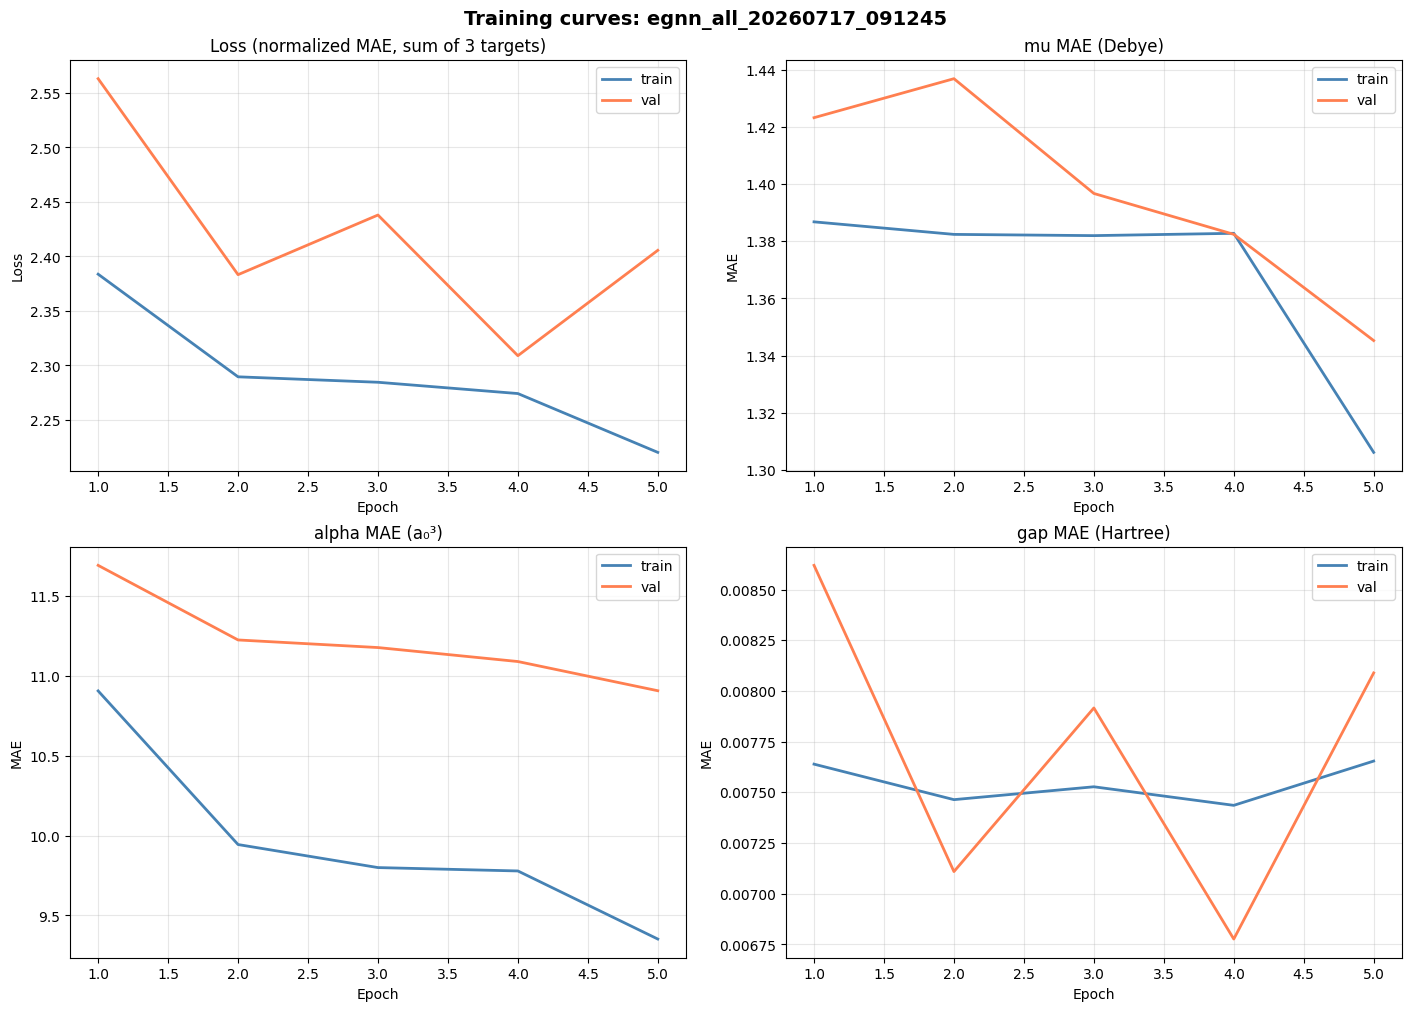

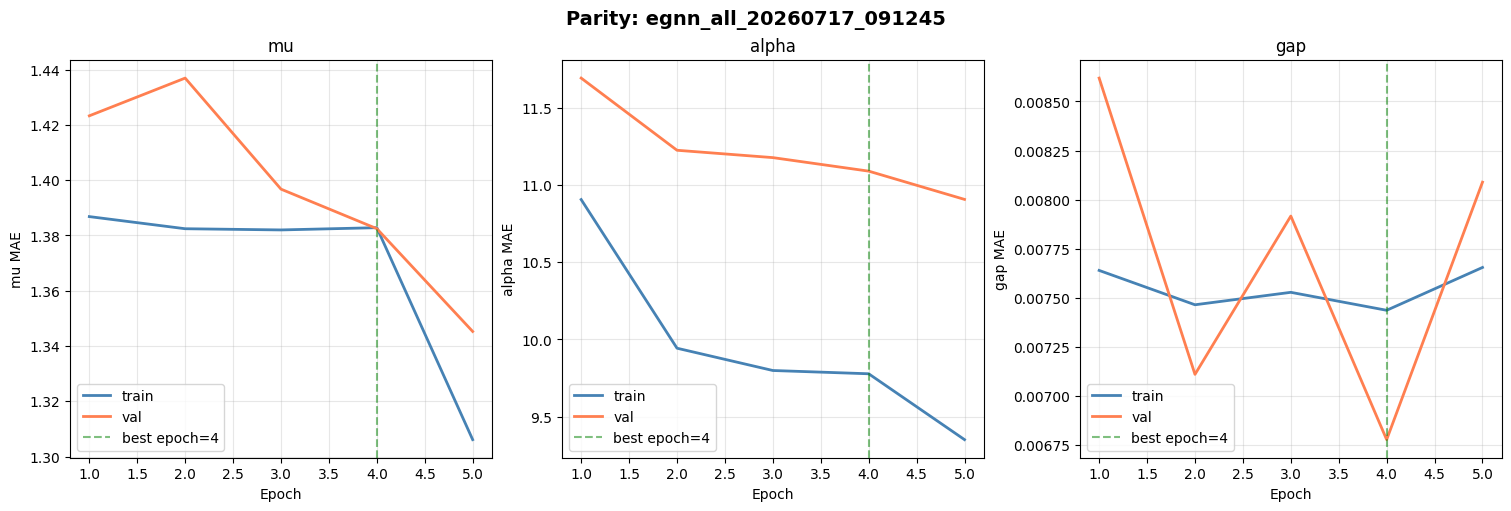

In [9]:
import sys
sys.path.insert(0, 'src')
from plot import plot_training_history, plot_parity, compare_histories
import glob, os

# Укажите путь к history CSV (замените на актуальный)
csv_path = 'results/smoke/history_egnn_all_20260717_091245.csv'  # smoke-test
# csv_path = 'results/experiments/batch_size_1024/history_egnn_all_20260712_160620.csv'  # полный

if os.path.exists(csv_path):
    plot_training_history(csv_path, show=True)
    plot_parity(csv_path, show=True)
else:
    print(f'CSV не найден: {csv_path}')
    print('Доступные history CSV:')
    for f in sorted(glob.glob('results/**/history_*.csv', recursive=True)):
        print(f'  {f}')

## 9. Robustness evaluation

Оценка устойчивости обученной модели к шуму в координатах (σ ∈ {0.0, 0.05, 0.10, 0.15}).

In [10]:
# Раскомментировать после обучения модели

# sys.argv = ['eval_robustness.py',
#     '--model', 'egnn', '--target', 'all',
#     '--checkpoint', 'checkpoints/egnn_all_best.pt',
#     '--target_stats', 'results/experiments/batch_size_1024/target_stats_egnn_all.json',
#     '--noise_sigma', '0.0,0.05,0.10,0.15',
#     '--device', 'cuda',
# ]
# from eval_robustness import main as eval_main
# eval_main()

## 10. AutoML — автоматический выбор архитектуры (программа максимум)

Извлекает геометрические priors из TDA и рекомендует оптимальную архитектуру.

Примечание: файл переименован из `select.py` в `run.py` (v33.2), чтобы избежать конфликта со стандартным модулем Python `select`.

In [11]:
import sys
sys.path.insert(0, 'src')
sys.path.insert(0, 'src/automl')

sys.argv = ['run.py',
    '--data_dir', 'data/alchemy',
    '--n_molecules', '30',
    '--threshold', '0.95',
    '--output_json', 'results/automl/recommendation.json',
]

# ВАЖНО: импорт из run, а не из select (конфликт со stdlib)
from run import main as automl_main
automl_main()

  AutoML: архитектурный выбор через TDA priors

[1/4] Загрузка молекул для extraction priors ...
Loading properties from data/alchemy/Alchemy-v20191129/final_version.csv ...
  Properties: 202579 molecules
Finding SDF files in data/alchemy/Alchemy-v20191129 ...
  Found: 202579 SDF files
  Valid: 202579
  Parsing SDF: 0/30
  Parsing SDF: 3/30
  Parsing SDF: 6/30
  Parsing SDF: 9/30
  Parsing SDF: 12/30
  Parsing SDF: 15/30
  Parsing SDF: 18/30
  Parsing SDF: 21/30
  Parsing SDF: 24/30
  Parsing SDF: 27/30
  Loaded: 30 molecules

[2/4] Извлечение геометрических priors ...
  TDA prior extraction: 0/30
  TDA prior extraction: 3/30
  TDA prior extraction: 6/30
  TDA prior extraction: 9/30
  TDA prior extraction: 12/30
  TDA prior extraction: 15/30
  TDA prior extraction: 18/30
  TDA prior extraction: 21/30
  TDA prior extraction: 24/30
  TDA prior extraction: 27/30

Extracted priors (n=30 molecules):
  translation_invariance:  1.0000
  rotation_invariance:     1.0000
  permutation_invariance

## 11. Просмотр отчёта AutoML

In [12]:
import json
from pathlib import Path

report_path = 'results/automl/recommendation.json'
if Path(report_path).exists():
    with open(report_path) as f:
        report = json.load(f)
    print('=== AutoML Report ===')
    print(f'Timestamp: {report["timestamp"]}')
    print(f'\nPriors (n={report["priors"]["n_molecules_success"]} molecules):')
    for k, v in report['priors'].items():
        if isinstance(v, float):
            print(f'  {k}: {v:.4f}')
    print(f'\nRecommendation:')
    for k, v in report['recommendation'].items():
        print(f'  {k}: {v}')
else:
    print(f'Отчёт не найден: {report_path}')

=== AutoML Report ===
Timestamp: 2026-07-19T15:53:10.031226

Priors (n=30 molecules):
  translation_invariance: 1.0000
  rotation_invariance: 1.0000
  permutation_invariance: 1.0000

Recommendation:
  required_invariances: ['translation', 'rotation', 'permutation']
  recommended_model: egnn
  needs_tda: True
  rationale: Все три E(3) симметрии присутствуют как сильные priors. Рекомендуется EGNN (E(3)-эквивариантная сеть). TDA-фичи могут дополнительно улучшить метрики через --tda_mode film.


## 12. Тесты (краткий вывод)

In [13]:
# Краткий вывод: -q (quiet), --tb=line (одна строка на ошибку)
!python -m pytest -q --tb=line 2>&1 #| tail -5

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0
rootdir: /kaggle/working/alchemy-geom-tda
configfile: pyproject.toml
testpaths: tests
plugins: anyio-4.13.0, typeguard-4.5.1, langsmith-0.7.34
collected 129 items                                                            

tests/test_data.py ..............                                        [ 10%]
tests/test_dataset_cache.py ............                                 [ 20%]
tests/test_early_stopping.py ...........                                 [ 28%]
tests/test_knn.py ..........                                             [ 36%]
tests/test_metrics.py .........                                          [ 43%]
tests/test_models.py ...............                                     [ 55%]
tests/test_physics.py .....................                              [ 71%]
tests/test_priors.py ..................                                  [

## Что дальше

1. **Полное обучение на GPU:** раскомментируйте ячейки 5-7, установите `--device cuda`.
2. **EGNN Tensor (часть B):** ячейка 6 — физически корректная модель с векторным μ и тензорным α.
3. **Robustness eval:** после обучения прогоните ячейку 9 на каждой модели.
4. **AutoML с quick_train:** добавьте `--quick_train --candidates fcnn,schnet,egnn,egnn_tda`.

См. `QUICKSTART.md` для краткой справки по CLI.